In [ ]:
library(tidyverse)

In [2]:
library(ggpubr)

In [3]:
Diff_box <- readRDS('Diff_forbox_comb.Rds')
EpiReg_box <- readRDS('EpiReg_order_forbox_comb.Rds')
KEGG_box <- readRDS('KEGG_order_forbox_comb.Rds')

In [4]:
Diff_box  %>% mutate(group = case_when(group=='All' ~ 'All',
                                           group=='C2' ~ 'Diff_C2',
                                           group=='C3' ~ 'Diff_C3')) -> Diff_box2

In [5]:
EpiReg_box  %>% mutate(group = case_when(group=='All' ~ 'All',
                                           group=='C2' ~ 'Epi_C2',
                                           group=='C3' ~ 'Epi_C3')) -> EpiReg_box2

In [6]:
KEGG_box  %>% mutate(group = case_when(group=='All' ~ 'All',
                                           group=='C2' ~ 'KEGG_C2',
                                           group=='C3' ~ 'KEGG_C3')) -> KEGG_box2

In [7]:
Diff_box2$group  %>% unique()

[1] "All"     "Diff_C2" "Diff_C3"

In [8]:
EpiReg_box2$group  %>% unique()

[1] "Epi_C2" "Epi_C3"

In [9]:
KEGG_box2$group  %>% unique()

[1] "KEGG_C2" "KEGG_C3"

In [10]:
rbind(Diff_box2,EpiReg_box2,KEGG_box2) -> allcombined

In [11]:
allcombined   %>% filter(str_detect(group,'C2')|str_detect(group,'All')) -> combined_C2
allcombined   %>% filter(str_detect(group,'C3')|str_detect(group,'All')) -> combined_C3

In [12]:
combined_C2$group  %>% unique()

[1] "All"     "Diff_C2" "Epi_C2"  "KEGG_C2"

In [13]:
compare_list <- list(c("Diff_C2","Epi_C2"),c("Diff_C2","KEGG_C2"),c("Epi_C2","KEGG_C2"),
                     c('All','Diff_C2'),c('All','Epi_C2'),c('All','KEGG_C2'))

In [14]:
combined_C2$group <- factor(combined_C2$group ,levels = c("All","Diff_C2","Epi_C2","KEGG_C2"))

In [15]:
p1_C2 <- ggboxplot(combined_C2,x="group",y="Proportion",add="jitter",add.params=list(shape=21, fill="orange", size=1.5)
         )+geom_signif(comparisons = compare_list,step_increase = 0.1,map_signif_level = F,test = t.test
                      )+ scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))+
        ylab("Proportion") + facet_wrap(~states, scale="free")+theme(axis.text.x = element_text(angle=45,hjust=1))

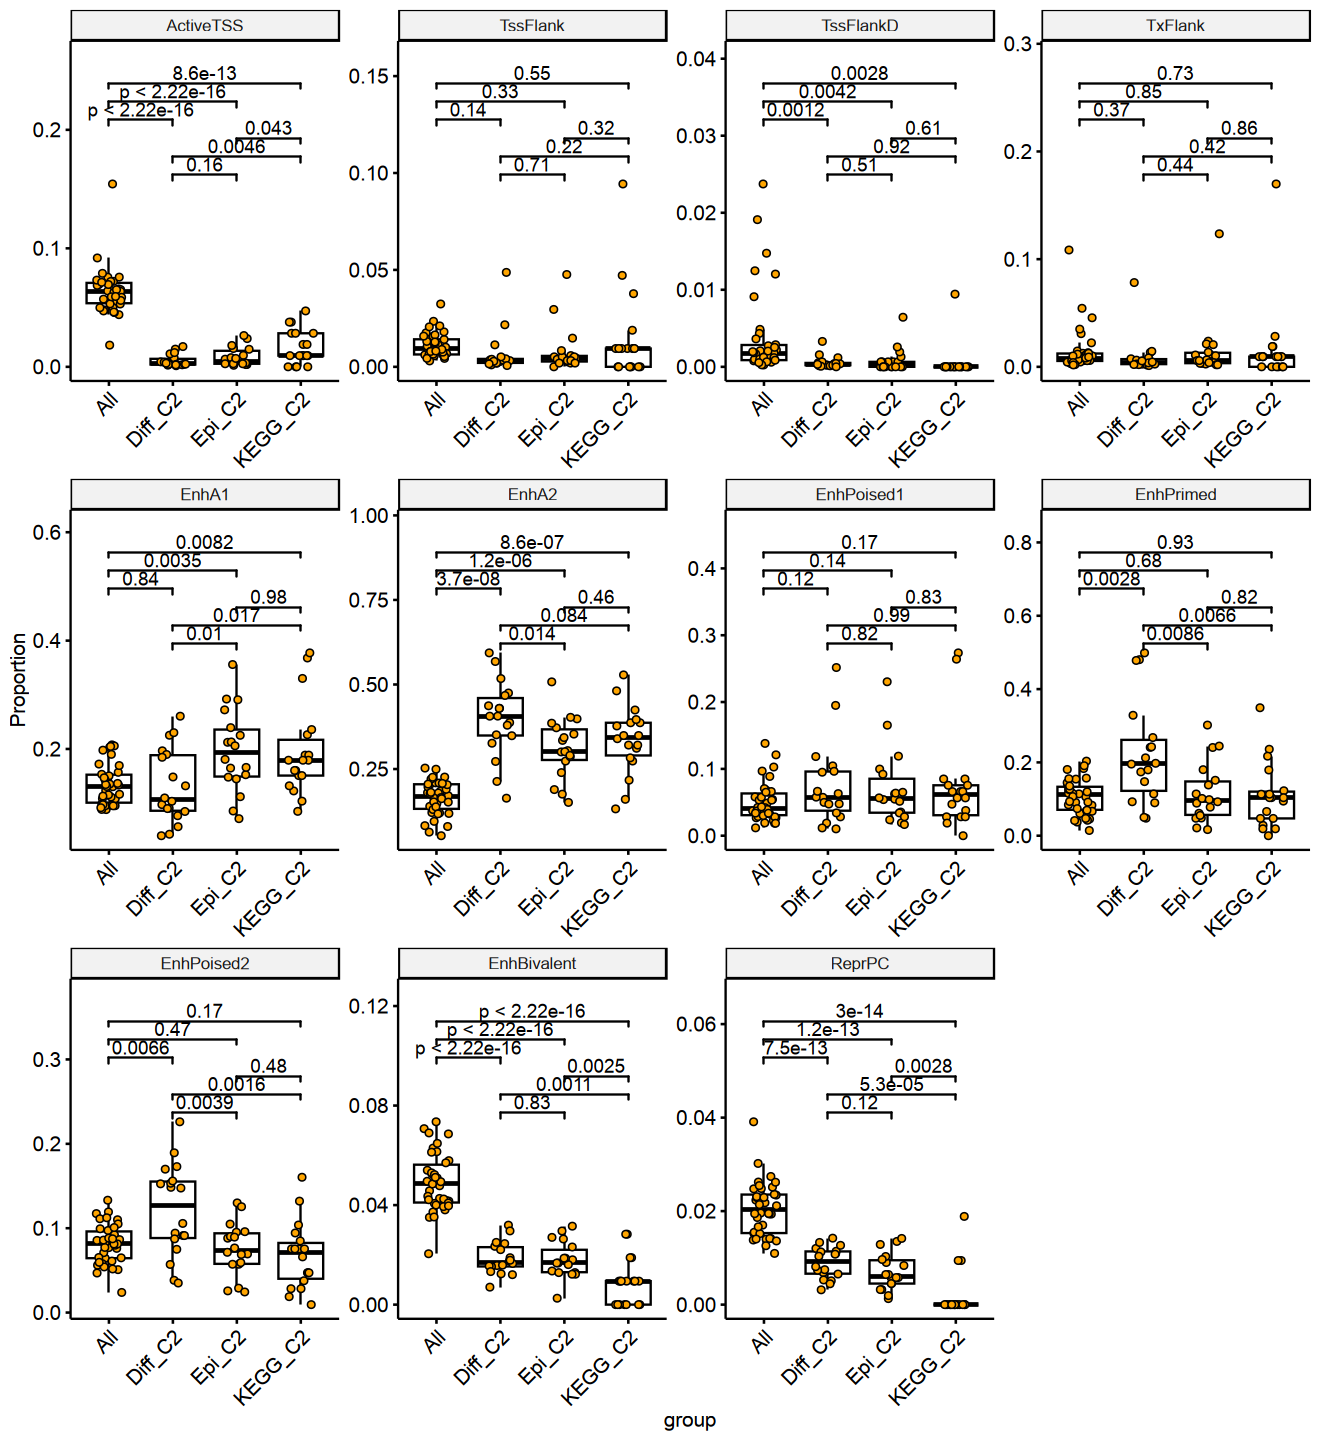

In [16]:
options(repr.plot.height=12,repr.plot.width=11)
p1_C2

In [17]:
ggsave(filename = "C2_chromHMM_box.pdf",plot =p1_C2 ,width = 11,height = 12)

In [18]:
compare_list2 <- list(c("Diff_C3","Epi_C3"),c("Diff_C3","KEGG_C3"),c("Epi_C3","KEGG_C3"),
                     c('All','Diff_C3'),c('All','Epi_C3'),c('All','KEGG_C3'))

In [19]:
combined_C3$group <- factor(combined_C3$group ,levels = c("All","Diff_C3","Epi_C3","KEGG_C3"))

In [20]:
p1_C3 <- ggboxplot(combined_C3,x="group",y="Proportion",add="jitter",add.params=list(shape=21, fill="orange", size=1.5)
         )+geom_signif(comparisons = compare_list2,step_increase = 0.1,map_signif_level = F,test = t.test
                      )+ scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))+
        ylab("Proportion") + facet_wrap(~states, scale="free")+theme(axis.text.x = element_text(angle=45,hjust=1))

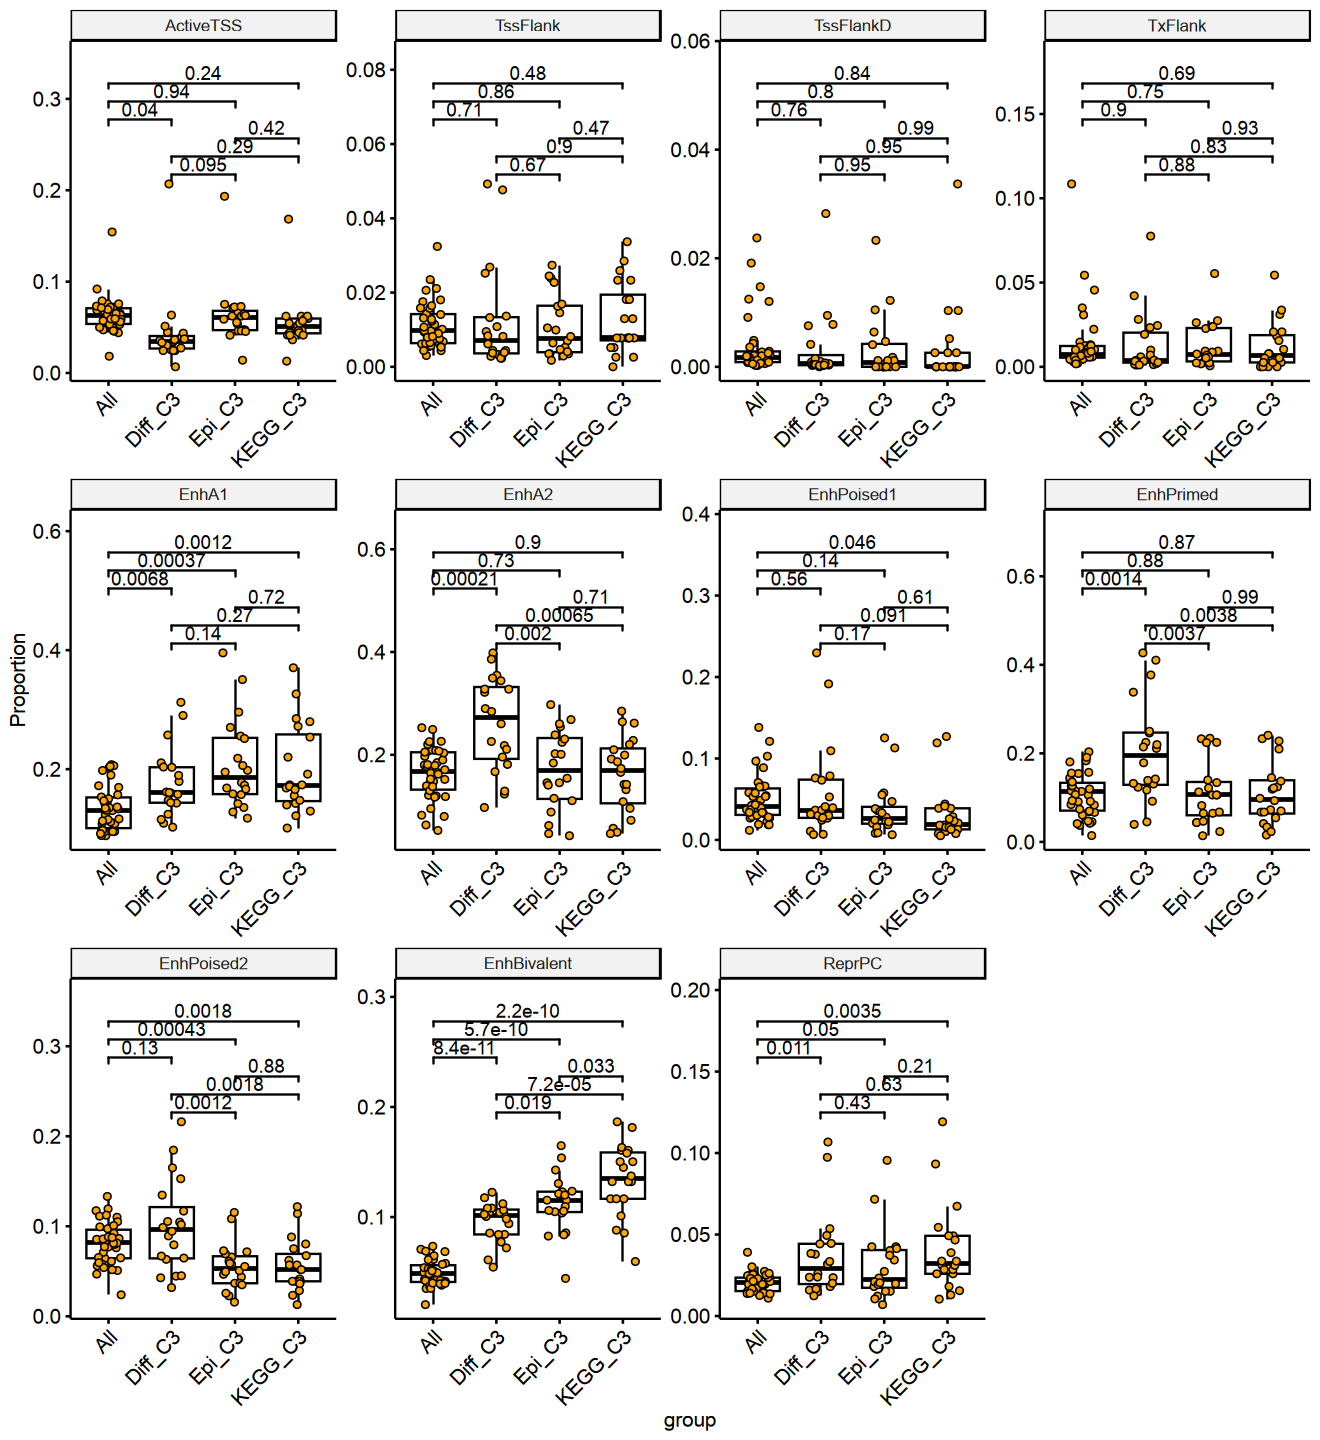

In [21]:
p1_C3

In [22]:
ggsave(filename = "C3_chromHMM_box.pdf",plot =p1_C3 ,width = 11,height = 12)

In [ ]:
combined_C2

In [28]:
library(dplyr)

combined_C2 %>%
  group_by(group,states) %>%
  reframe(
    q0   = quantile(Proportion, 0),
    q25  = quantile(Proportion, 0.25),
    median = quantile(Proportion, 0.5),
    q75  = quantile(Proportion, 0.75),
    q100 = quantile(Proportion, 1)
  )  %>% arrange(states) -> box_stats_C2

In [29]:
library(dplyr)

combined_C3 %>%
  group_by(group,states) %>%
  reframe(
    q0   = quantile(Proportion, 0),
    q25  = quantile(Proportion, 0.25),
    median = quantile(Proportion, 0.5),
    q75  = quantile(Proportion, 0.75),
    q100 = quantile(Proportion, 1)
  )  %>% arrange(states) -> box_stats_C3

In [30]:
box_stats_C3

group,states,q0,q25,median,q75,q100
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
All,ActiveTSS,0.0182951496,0.0536676987,0.0632074303,0.070835913,0.15431992
Diff_C3,ActiveTSS,0.0067394095,0.0267726874,0.0347292106,0.040444457,0.20687584
Epi_C3,ActiveTSS,0.0139778684,0.0468841002,0.0605707630,0.067996506,0.19336051
KEGG_C3,ActiveTSS,0.0129533679,0.0433937824,0.0505181347,0.059585492,0.16839378
All,TssFlank,0.0030381837,0.0063715170,0.0096759546,0.014198142,0.03242105
Diff_C3,TssFlank,0.0023100023,0.0036168346,0.0071764206,0.013360931,0.04924186
Epi_C3,TssFlank,0.0017472335,0.0039312755,0.0075713454,0.016453116,0.02737333
KEGG_C3,TssFlank,0.0000000000,0.0071243523,0.0077720207,0.019430052,0.03367876
All,TssFlankD,0.0002394221,0.0008668731,0.0017254902,0.002831785,0.02373581


In [31]:
box_stats_C2  %>% filter(group %in% c('Diff_C2','KEGG_C2')) -> box_stats_C2

In [32]:
box_stats_C3  %>% filter(group %in% c('Diff_C3','KEGG_C3')) -> box_stats_C3

In [33]:
openxlsx::write.xlsx(list(C2 = box_stats_C2,C3 = box_stats_C3),file = "KEGG_ChromHMM_stats.xlsx")

In [23]:
save.image('box.Rds')